# 🧠 Brain Tumor MRI Classification — VGG16 Transfer Learning
### Kaggle Notebook (P100 GPU)

**Dataset:** 12,064 T1-weighted contrast-enhanced MRI images  
**Classes:** Glioma · Meningioma · Pituitary · No Tumor  
**Architecture:** VGG16 (ImageNet weights) + custom classification head  
**Strategy:** Two-phase training → head only → fine-tune top 30 VGG16 layers  

---
| Phase | Layers trained | LR | Epochs |
|-------|---------------|-----|--------|
| 1 | Head only (GAP → Dense → Dropout → Dense) | 1e-4 | 20 |
| 2 | Head + last 30 VGG16 layers | 1e-5 | 20 |

> **Expected results (from local run):** ~98% test accuracy, macro AUC ~0.998

## 1 — Environment & GPU Check

In [1]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import load_model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc as sklearn_auc
)
from sklearn.preprocessing import label_binarize
from PIL import Image

print(f"TensorFlow  : {tf.__version__}")
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print()

# GPU info
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"✅ GPU found : {gpu}")
    # Allow memory growth so TF doesn't grab all VRAM at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU found — running on CPU (will be slow)")

# Confirm P100 via nvidia-smi
os.system('nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || echo "nvidia-smi not available"')

2026-03-11 12:06:52.031110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773230812.214584      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773230812.264692      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773230812.676092      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773230812.676132      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773230812.676135      55 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.0
Python      : 3.12.12
NumPy       : 2.0.2

✅ GPU found : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Tesla P100-PCIE-16GB, 16384 MiB


0

## 2 — Dataset Paths

**On Kaggle:** Add the dataset to your notebook via  
`+ Add Data` → search **Brain Tumor MRI Dataset**  

The dataset will be mounted at `/kaggle/input/brain-tumor-mri-dataset/`  
with subfolders `Training/` and `Testing/`.

> If your dataset uses different folder names, update `TRAIN_DIR` and `TEST_DIR` below.

In [7]:
# ── Kaggle dataset path ───────────────────────────────────────────────────────
# Standard Kaggle mount point — update slug if yours differs
DATASET_BASE = '/kaggle/input/datasets/rahulrathod7/brain-tumor-1/Epic and CSCR hospital Dataset'

# Some versions of this dataset use Training/Testing, others train/test
# Auto-detect which naming convention your dataset uses
if os.path.isdir(os.path.join(DATASET_BASE, 'Training')):
    TRAIN_DIR = os.path.join(DATASET_BASE, 'Training')
    TEST_DIR  = os.path.join(DATASET_BASE, 'Testing')
    print("Detected folder naming: Training / Testing")
elif os.path.isdir(os.path.join(DATASET_BASE, 'Train')):
    TRAIN_DIR = os.path.join(DATASET_BASE, 'Train')
    TEST_DIR  = os.path.join(DATASET_BASE, 'Test')
    print("Detected folder naming: train / test")
else:
    # List what's actually there to help debug
    print("⚠️  Could not auto-detect train folder. Contents of dataset root:")
    for item in sorted(os.listdir(DATASET_BASE)):
        print(f"  {item}/")
    raise FileNotFoundError(
        "Update TRAIN_DIR and TEST_DIR manually to match your dataset structure."
    )

# ── Output dirs (Kaggle working directory) ────────────────────────────────────
WORK_DIR    = '/kaggle/working'
MODEL_DIR   = os.path.join(WORK_DIR, 'models')
PLOTS_DIR   = os.path.join(WORK_DIR, 'plots')
REPORTS_DIR = os.path.join(WORK_DIR, 'reports')

for d in [MODEL_DIR, PLOTS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

BEST_MODEL_PATH  = os.path.join(MODEL_DIR, 'brain_tumor_vgg16.keras')
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'final_model.keras')

print(f"\nTrain dir   : {TRAIN_DIR}")
print(f"Test dir    : {TEST_DIR}")
print(f"Models dir  : {MODEL_DIR}")
print(f"Plots dir   : {PLOTS_DIR}")

Detected folder naming: train / test

Train dir   : /kaggle/input/datasets/rahulrathod7/brain-tumor-1/Epic and CSCR hospital Dataset/Train
Test dir    : /kaggle/input/datasets/rahulrathod7/brain-tumor-1/Epic and CSCR hospital Dataset/Test
Models dir  : /kaggle/working/models
Plots dir   : /kaggle/working/plots


## 3 — Hyperparameters & Class Names

In [8]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32          # P100 has 16 GB VRAM — 32 is safe, try 64 if you want
RANDOM_SEED   = 42

PHASE1_EPOCHS = 30
PHASE2_EPOCHS = 20
LEARNING_RATE = 1e-4
FINE_TUNE_LR  = 1e-5
PATIENCE      = 5
UNFREEZE_FROM = -30         # unfreeze last 30 VGG16 layers in Phase 2

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Class names — must match your folder names exactly (case-sensitive) ───────
# Auto-detect from whatever subfolder names are actually on disk
raw_classes = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
print(f"Folders found in train dir: {raw_classes}")

# Canonical order we want (adjust if your folder names differ)
PREFERRED_ORDER = ['Glioma', 'Meningioma', 'Pituitary', 'No_Tumor',
                   'glioma', 'meningioma', 'pituitary', 'notumor', 'no_tumor']

CLASSES = [c for c in PREFERRED_ORDER if c in raw_classes]
# Add any remaining classes not in preferred list
CLASSES += [c for c in raw_classes if c not in CLASSES]
NUM_CLASSES = len(CLASSES)

print(f"\nUsing class order : {CLASSES}")
print(f"NUM_CLASSES       : {NUM_CLASSES}")

Folders found in train dir: ['glioma', 'meningioma', 'notumor', 'pituitary']

Using class order : ['glioma', 'meningioma', 'pituitary', 'notumor']
NUM_CLASSES       : 4


## 4 — Dataset Statistics

Class               Train     Test    Total
──────────────────────────────────────────────
  glioma            3,018      755    3,773
  meningioma        2,183      546    2,729
  pituitary         2,504      626    3,130
  notumor           1,945      487    2,432
──────────────────────────────────────────────
  TOTAL             9,650    2,414   12,064


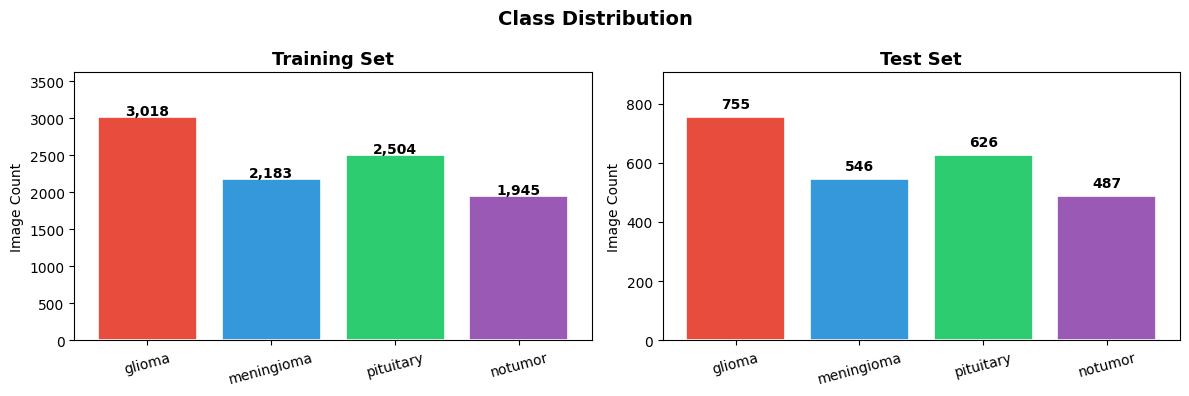

In [9]:
def count_images(base_dir, classes):
    counts = {}
    for cls in classes:
        cls_dir = os.path.join(base_dir, cls)
        n = 0
        if os.path.isdir(cls_dir):
            n = len([f for f in os.listdir(cls_dir)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
        counts[cls] = n
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts  = count_images(TEST_DIR,  CLASSES)

print(f"{'Class':<16} {'Train':>8} {'Test':>8} {'Total':>8}")
print("─" * 46)
for cls in CLASSES:
    tot = train_counts[cls] + test_counts[cls]
    print(f"  {cls:<14} {train_counts[cls]:>8,} {test_counts[cls]:>8,} {tot:>8,}")
print("─" * 46)
tr = sum(train_counts.values())
te = sum(test_counts.values())
print(f"  {'TOTAL':<14} {tr:>8,} {te:>8,} {tr+te:>8,}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#E74C3C','#3498DB','#2ECC71','#9B59B6'][:NUM_CLASSES]
for ax, counts, title in zip(axes, [train_counts, test_counts], ['Training Set','Test Set']):
    vals = [counts[c] for c in CLASSES]
    bars = ax.bar(CLASSES, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Image Count')
    ax.set_ylim(0, max(vals)*1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f'{v:,}', ha='center', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=15)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR,'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## 5 — Data Generators

Augmentation (train only): rotation ±20°, shift ±20%, shear, zoom, horizontal flip.  
All splits use VGG16 channel-mean preprocessing (`preprocess_input`).

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,
)

common = dict(
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,     # deterministic label ordering
    seed=RANDOM_SEED,
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, subset='training',   shuffle=True,  **common)
val_gen   = train_datagen.flow_from_directory(
    TRAIN_DIR, subset='validation', shuffle=False, **common)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, shuffle=False, **common)

print(f"Label map     : {train_gen.class_indices}")
print(f"Train samples : {train_gen.samples:,}  ({len(train_gen)} batches)")
print(f"Val   samples : {val_gen.samples:,}  ({len(val_gen)} batches)")
print(f"Test  samples : {test_gen.samples:,}  ({len(test_gen)} batches)")

Found 7722 images belonging to 4 classes.
Found 1928 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.
Label map     : {'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'notumor': 3}
Train samples : 7,722  (242 batches)
Val   samples : 1,928  (61 batches)
Test  samples : 2,414  (76 batches)


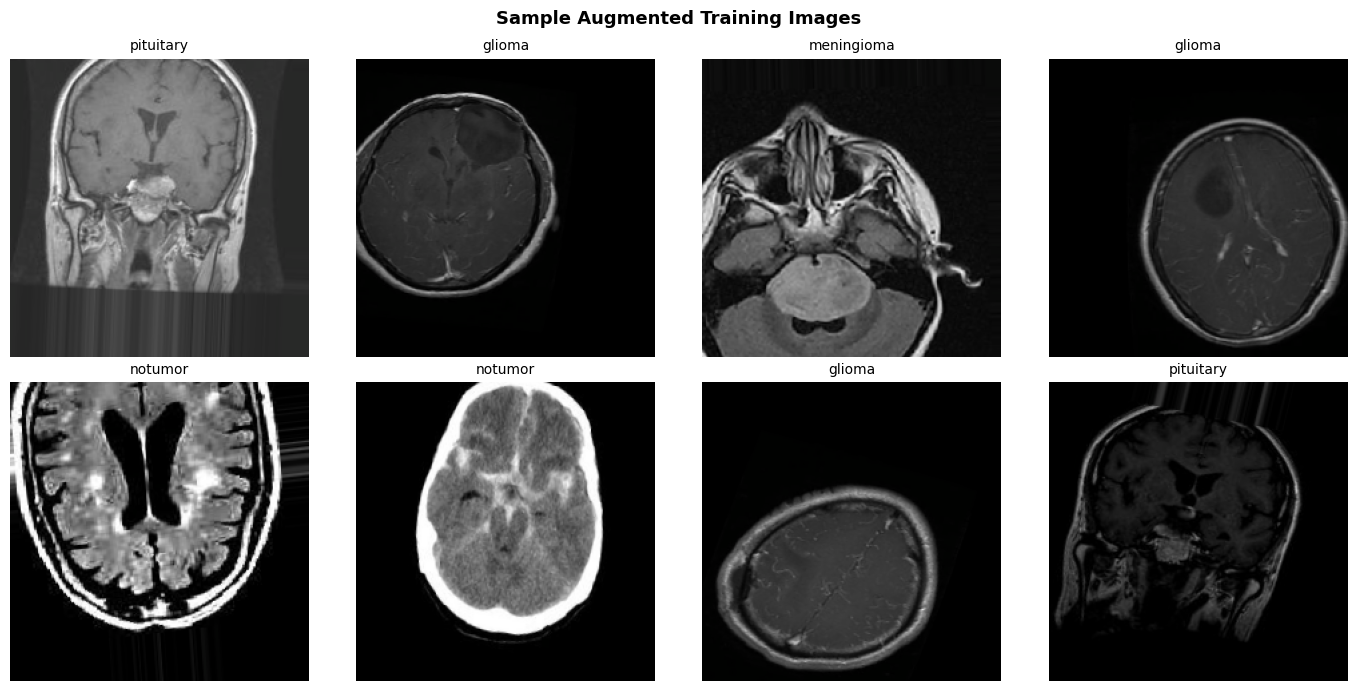

In [11]:
# Sample images (undo VGG16 preprocessing for display)
mean_bgr = np.array([103.939, 116.779, 123.68])
def undo_preprocess(img):
    return np.clip((img + mean_bgr) / 255.0, 0, 1)

batch_imgs, batch_lbls = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Augmented Training Images', fontsize=13, fontweight='bold')
for ax, img, lbl in zip(axes.flat, batch_imgs[:8], batch_lbls[:8]):
    ax.imshow(undo_preprocess(img))
    ax.set_title(CLASSES[np.argmax(lbl)], fontsize=10)
    ax.axis('off')
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR,'sample_augmented.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## 6 — Class Weights

Balances the loss so minority classes aren't ignored during training.

In [12]:
y_labels       = train_gen.classes
unique_cls     = np.unique(y_labels)
weights        = compute_class_weight('balanced', classes=unique_cls, y=y_labels)
class_weight_dict = dict(zip(unique_cls.tolist(), weights.tolist()))

print("Class weights:")
for idx, w in class_weight_dict.items():
    print(f"  [{idx}] {CLASSES[idx]:<16}  {w:.4f}")

Class weights:
  [0] glioma            0.7994
  [1] meningioma        1.1050
  [2] pituitary         0.9633
  [3] notumor           1.2407


## 7 — Model Architecture

```
Input (224 × 224 × 3)
    ↓
VGG16 backbone — 13 conv layers, 5 max-pool blocks  [frozen in Phase 1]
    ↓  output: (7 × 7 × 512)
GlobalAveragePooling2D
    ↓  (512,)
Dense(256, ReLU)
    ↓
Dropout(0.5)
    ↓
Dense(4, Softmax)
```

**Functional API** is used (not `Sequential`) so that `layer.output` tensors are  
accessible for Grad-CAM and fine-tuning.

In [13]:
def build_model(freeze_base=True):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = not freeze_base

    inputs  = base.input
    x       = base.output
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='brain_tumor_vgg16')
    return model, base

model, base_model = build_model(freeze_base=True)
model.summary()

total      = model.count_params()
trainable_params  = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen     = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"\nTotal params        : {total:,}")
print(f"Trainable params    : {trainable_params:,}")
print(f"Frozen params       : {frozen:,}")

I0000 00:00:1773230967.842031      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "brain_tumor_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Total params        : 14,847,044
Trainable params    : 132,356
Frozen params       : 14,714,688


## 8 — Training Helpers

In [14]:
def make_callbacks():
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=PATIENCE,
            restore_best_weights=True, verbose=1,
        ),
        ModelCheckpoint(
            BEST_MODEL_PATH, save_best_only=True,
            monitor='val_accuracy', mode='max', verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.2,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_history(history, title, suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, metric, label in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
        ax.plot(history.history[metric],          label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path = os.path.join(PLOTS_DIR, f'history{suffix}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Saved → {path}")

print("✅ Helpers ready.")

✅ Helpers ready.


## 9 — Phase 1: Train Classification Head

VGG16 base is **fully frozen** — only the 3 new layers are updated.  
LR = `1e-4`, up to 20 epochs (EarlyStopping patience = 5).

In [15]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Phase 1 — trainable params: {trainable_params:,}")
print(f"Learning rate             : {LEARNING_RATE}\n")

t0 = time.time()
history1 = model.fit(
    train_gen,
    epochs=PHASE1_EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(),
)
phase1_time = time.time() - t0
print(f"\n⏱  Phase 1 done in {phase1_time/60:.1f} min")

Phase 1 — trainable params: 132,356
Learning rate             : 0.0001

Epoch 1/30


I0000 00:00:1773230988.594536     161 service.cc:152] XLA service 0x794dbc00cc20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773230988.594576     161 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773230989.102870     161 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/242 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.2891 - loss: 5.3229 

I0000 00:00:1773230997.413269     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.3538 - loss: 3.4927
Epoch 1: val_accuracy improved from -inf to 0.69969, saving model to /kaggle/working/models/brain_tumor_vgg16.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 164s 638ms/step - accuracy: 0.3542 - loss: 3.4885 - val_accuracy: 0.6997 - val_loss: 0.8569 - learning_rate: 1.0000e-04
Epoch 2/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.6247 - loss: 1.1747
Epoch 2: val_accuracy improved from 0.69969 to 0.75000, saving model to /kaggle/working/models/brain_tumor_vgg16.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 114s 471ms/step - accuracy: 0.6248 - loss: 1.1742 - val_accuracy: 0.7500 - val_loss: 0.7120 - learning_rate: 1.0000e-04
Epoch 3/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.6970 - loss: 0.8358
Epoch 3: val_accuracy improved from 0.75000 to 0.76556, saving model to /kaggle/working/models/brain_tumor_vgg16.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 116s 479ms/step - accuracy: 0.6971 - loss: 0.8357 - val_accuracy: 

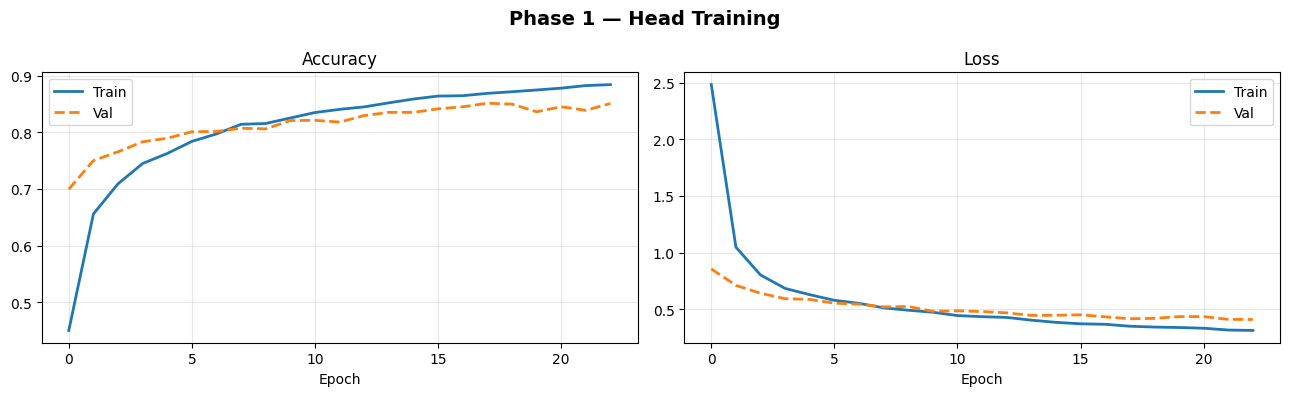

Saved → /kaggle/working/plots/history_phase1.png
Best epoch        : 18
Best val accuracy : 0.8511
Best val loss     : 0.4179


In [16]:
plot_history(history1, 'Phase 1 — Head Training', '_phase1')

best1 = np.argmax(history1.history['val_accuracy'])
print(f"Best epoch        : {best1 + 1}")
print(f"Best val accuracy : {history1.history['val_accuracy'][best1]:.4f}")
print(f"Best val loss     : {history1.history['val_loss'][best1]:.4f}")

## 10 — Phase 2: Fine-tune Top VGG16 Layers

Unfreeze the **last 30 layers** of VGG16. Earlier layers stay frozen (universal low-level features).  
LR = `1e-5` (10× smaller to avoid destroying pre-trained weights).

In [17]:
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

unfrozen = [l.name for l in base_model.layers if l.trainable]
print(f"Unfrozen VGG16 layers ({len(unfrozen)}):")
for name in unfrozen:
    print(f"  • {name}")

# Recompile REQUIRED after changing trainable flags
model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"\nPhase 2 — trainable params: {trainable_params:,}")
print(f"Learning rate             : {FINE_TUNE_LR}\n")

t0 = time.time()
history2 = model.fit(
    train_gen,
    epochs=PHASE2_EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(),
)
phase2_time = time.time() - t0
print(f"\n⏱  Phase 2 done in {phase2_time/60:.1f} min")

Unfrozen VGG16 layers (19):
  • input_layer
  • block1_conv1
  • block1_conv2
  • block1_pool
  • block2_conv1
  • block2_conv2
  • block2_pool
  • block3_conv1
  • block3_conv2
  • block3_conv3
  • block3_pool
  • block4_conv1
  • block4_conv2
  • block4_conv3
  • block4_pool
  • block5_conv1
  • block5_conv2
  • block5_conv3
  • block5_pool

Phase 2 — trainable params: 14,847,044
Learning rate             : 1e-05

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8580 - loss: 0.3782
Epoch 1: val_accuracy improved from -inf to 0.87967, saving model to /kaggle/working/models/brain_tumor_vgg16.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 165s 585ms/step - accuracy: 0.8581 - loss: 0.3780 - val_accuracy: 0.8797 - val_loss: 0.3415 - learning_rate: 1.0000e-05
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9123 - loss: 0.2459
Epoch 2: val_accuracy improved from 0.87967 to 0.91649, saving model to /kaggle/working/models/brain_tumor_vgg16.keras
242/242 ━━━━━━━━━━━━

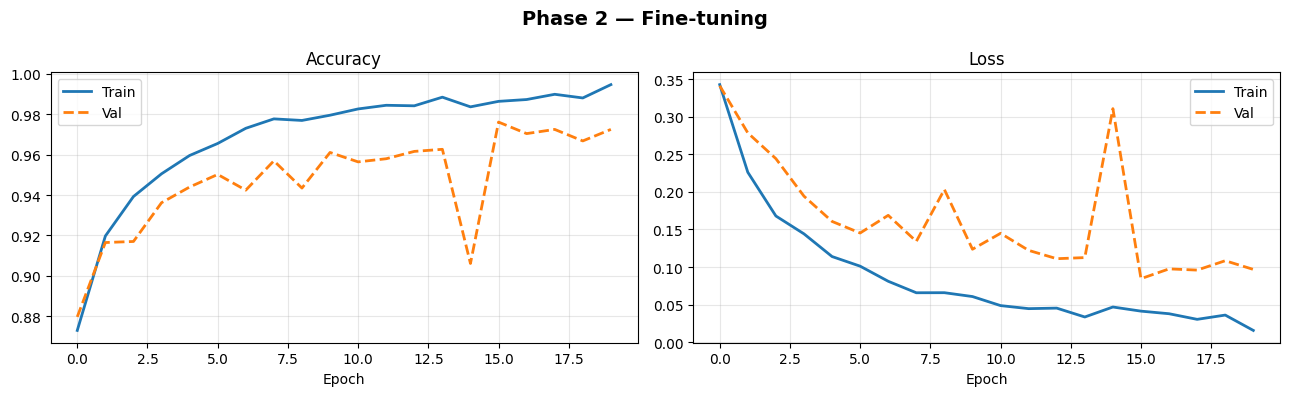

Saved → /kaggle/working/plots/history_phase2.png
Best epoch        : 16
Best val accuracy : 0.9761
Best val loss     : 0.0845


In [19]:
plot_history(history2, 'Phase 2 — Fine-tuning', '_phase2')

best2 = np.argmax(history2.history['val_accuracy'])
print(f"Best epoch        : {best2 + 1}")
print(f"Best val accuracy : {history2.history['val_accuracy'][best2]:.4f}")
print(f"Best val loss     : {history2.history['val_loss'][best2]:.4f}")

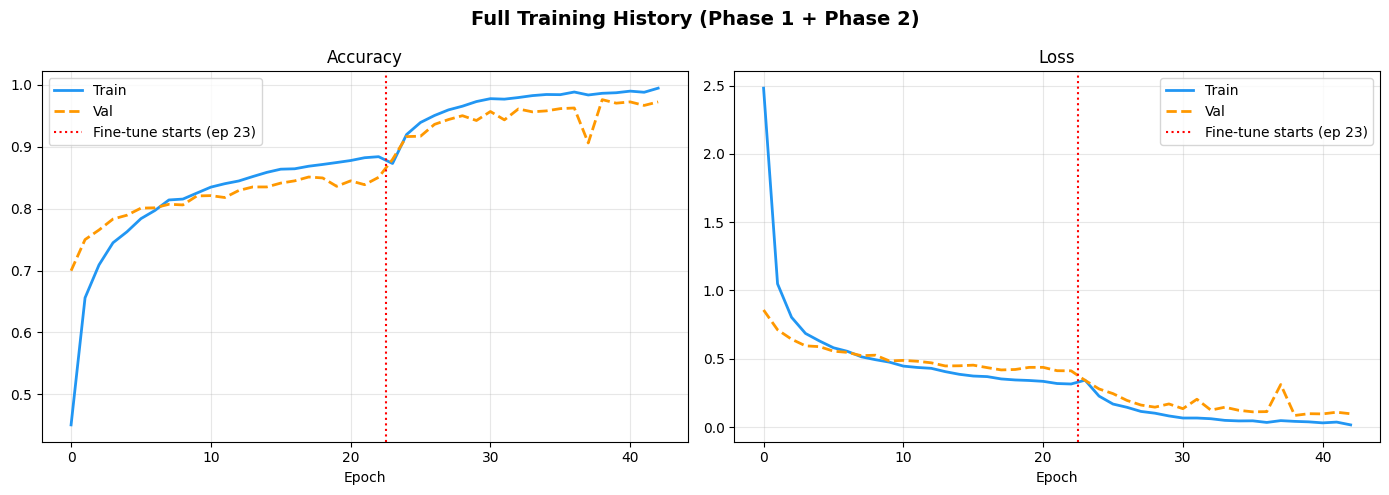

Saved → /kaggle/working/plots/history_combined.png


In [21]:
# Combined curve across both phases
def merge_histories(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

combined   = merge_histories(history1, history2)
p1_end     = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Full Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')
for ax, metric, label in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(combined[metric],          label='Train', linewidth=2, color='#2196F3')
    ax.plot(combined[f'val_{metric}'], label='Val',   linewidth=2, color='#FF9800', linestyle='--')
    ax.axvline(p1_end - 0.5, color='red', linestyle=':', linewidth=1.5,
               label=f'Fine-tune starts (ep {p1_end})')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.tight_layout()
path = os.path.join(PLOTS_DIR, 'history_combined.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved → {path}")

## 11 — Evaluation on Test Set

In [22]:
# Load best checkpoint saved by ModelCheckpoint
best_model = load_model(BEST_MODEL_PATH, compile=False)
print(f"✅ Best model loaded from {BEST_MODEL_PATH}")

# Load test images with deterministic label order
class_to_idx = {cls: i for i, cls in enumerate(CLASSES)}
X_test, y_true = [], []

print("\nLoading test images …")
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_dir):
        print(f"  ⚠️  Not found: {cls_dir}")
        continue
    loaded = 0
    for fname in sorted(os.listdir(cls_dir)):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')):
            continue
        try:
            img = keras_image.load_img(os.path.join(cls_dir, fname), target_size=IMG_SIZE)
            arr = preprocess_input(keras_image.img_to_array(img))
            X_test.append(arr)
            y_true.append(class_to_idx[cls])
            loaded += 1
        except Exception as e:
            pass
    print(f"  {cls:<16} {loaded:>4} images")

X_test = np.array(X_test, dtype=np.float32)
y_true = np.array(y_true, dtype=np.int32)
print(f"\nTotal: {len(X_test):,} test images")

✅ Best model loaded from /kaggle/working/models/brain_tumor_vgg16.keras

Loading test images …
  glioma            755 images
  meningioma        546 images
  pituitary         626 images
  notumor           487 images

Total: 2,414 test images


In [24]:
# Batch inference
parts = []
for i in range(0, len(X_test), BATCH_SIZE):
    preds = best_model.predict(X_test[i:i+BATCH_SIZE], verbose=0)
    parts.append(preds)
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  Batch {i//BATCH_SIZE + 1}/{(len(X_test)+BATCH_SIZE-1)//BATCH_SIZE}")

y_pred_prob = np.concatenate(parts, axis=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
print("\nInference complete.")

  Batch 1/76
  Batch 11/76
  Batch 21/76
  Batch 31/76
  Batch 41/76
  Batch 51/76
  Batch 61/76
  Batch 71/76

Inference complete.


In [25]:
# Classification report
report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print("Classification Report:")
print(report)
with open(os.path.join(REPORTS_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9756    0.9536    0.9645       755
  meningioma     0.9529    0.9634    0.9581       546
   pituitary     0.9952    1.0000    0.9976       626
     notumor     0.9838    1.0000    0.9919       487

    accuracy                         0.9772      2414
   macro avg     0.9769    0.9793    0.9780      2414
weighted avg     0.9772    0.9772    0.9772      2414



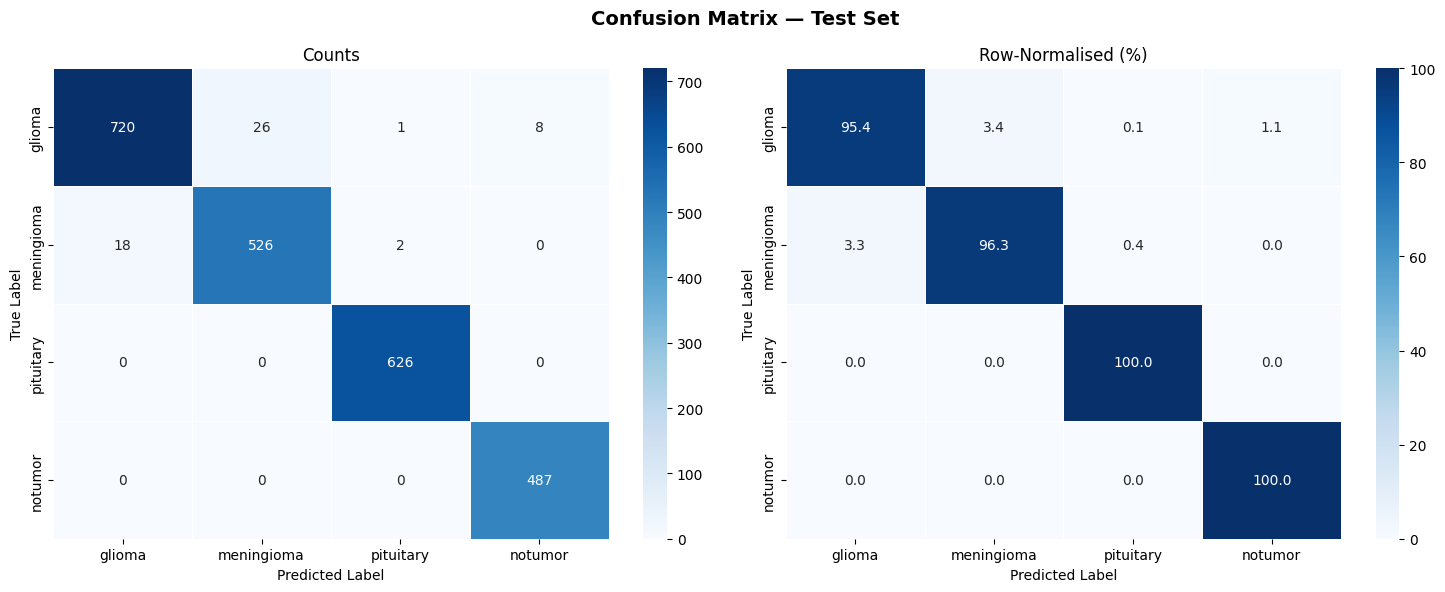

Saved → /kaggle/working/plots/confusion_matrix.png


In [26]:
# Confusion matrix — counts + row-normalised %
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            linewidths=0.5, linecolor='white', vmin=0, vmax=100)
axes[1].set_title('Row-Normalised (%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.tight_layout()
path = os.path.join(PLOTS_DIR, 'confusion_matrix.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved → {path}")

Per-class AUC-ROC:
  glioma           0.9962
  meningioma       0.9973
  pituitary        1.0000
  notumor          0.9997

  Macro AUC : 0.9983


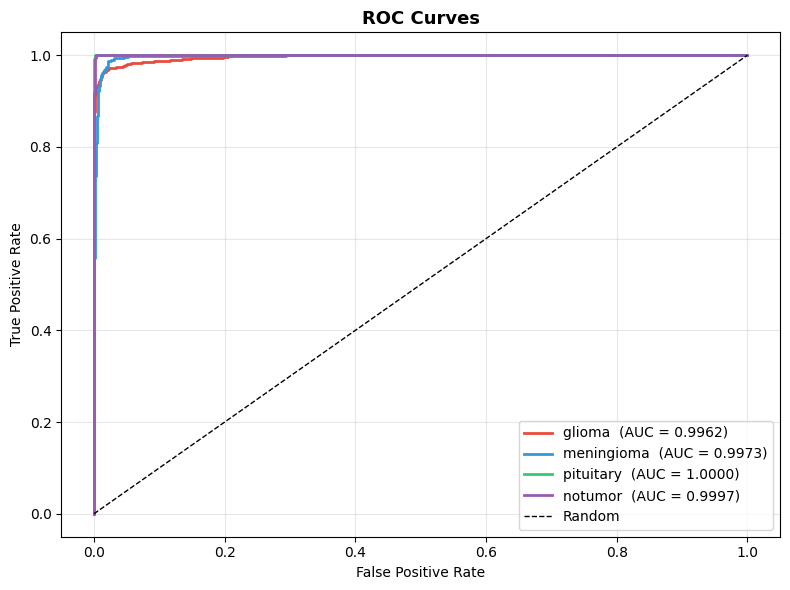

Saved → /kaggle/working/plots/roc_curves.png


In [27]:
# ROC curves + AUC
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_scores = roc_auc_score(y_true_bin, y_pred_prob, average=None)

print("Per-class AUC-ROC:")
for cls, s in zip(CLASSES, auc_scores):
    print(f"  {cls:<16} {s:.4f}")
print(f"\n  Macro AUC : {np.mean(auc_scores):.4f}")

colors = ['#E74C3C','#3498DB','#2ECC71','#9B59B6'][:NUM_CLASSES]
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls}  (AUC = {auc_scores[i]:.4f})')
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
path = os.path.join(PLOTS_DIR, 'roc_curves.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved → {path}")

## 12 — Grad-CAM Visualisation

Highlights which regions of the MRI the model focuses on.  
🔴 Red/yellow = high attention · 🔵 Blue = low attention

In [29]:
# ── Grad-CAM implementation (self-contained, no src/ needed on Kaggle) ───────

def find_last_conv_layer(model):
    conv_types = (
        tf.keras.layers.Conv2D,
        tf.keras.layers.SeparableConv2D,
        tf.keras.layers.DepthwiseConv2D,
    )
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            result = find_last_conv_layer(layer)
            if result is not None:
                return result
        if isinstance(layer, conv_types):
            return layer
    return None

def make_gradcam_heatmap(img_array, model, pred_index=None):
    if img_array.ndim == 3:
        img_array = np.expand_dims(img_array, axis=0)
    img_tensor = tf.cast(img_array, tf.float32)

    target_layer = find_last_conv_layer(model)
    if target_layer is None:
        raise ValueError("No Conv2D layer found in model.")

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        score = preds[:, pred_index]

    grads   = tape.gradient(score, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    max_val = float(tf.reduce_max(heatmap))
    if max_val == 0.0:
        return np.zeros(heatmap.shape, dtype=np.float32)
    return (heatmap / max_val).numpy().astype(np.float32)

def overlay_heatmap(heatmap, original_img, alpha=0.45):
    if hasattr(original_img, 'convert'):
        original_img = np.array(original_img.convert('RGB'))
    original_img = np.asarray(original_img)
    if original_img.dtype != np.uint8:
        scale = 255.0 if original_img.max() <= 1.0 else 1.0
        original_img = np.clip(original_img * scale, 0, 255).astype(np.uint8)

    heatmap = np.nan_to_num(np.clip(np.squeeze(heatmap), 0.0, 1.0))
    h, w    = original_img.shape[:2]
    heatmap = cv2.resize(heatmap, (w, h))

    lo, hi  = heatmap.min(), heatmap.max()
    if hi > lo:
        heatmap = (heatmap - lo) / (hi - lo)
    heatmap = np.power(heatmap, 0.7)

    heatmap_u8    = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    alpha_mask = heatmap[..., None] * alpha
    blended    = (original_img.astype(np.float32) * (1.0 - alpha_mask)
                  + heatmap_color.astype(np.float32) * alpha_mask)
    return np.clip(blended, 0, 255).astype(np.uint8)

last_conv = find_last_conv_layer(best_model)
if last_conv is not None:
    print(f"✅ Target conv layer : {last_conv.name}")
else:
    print("❌ No conv layer found")

✅ Target conv layer : block5_conv3


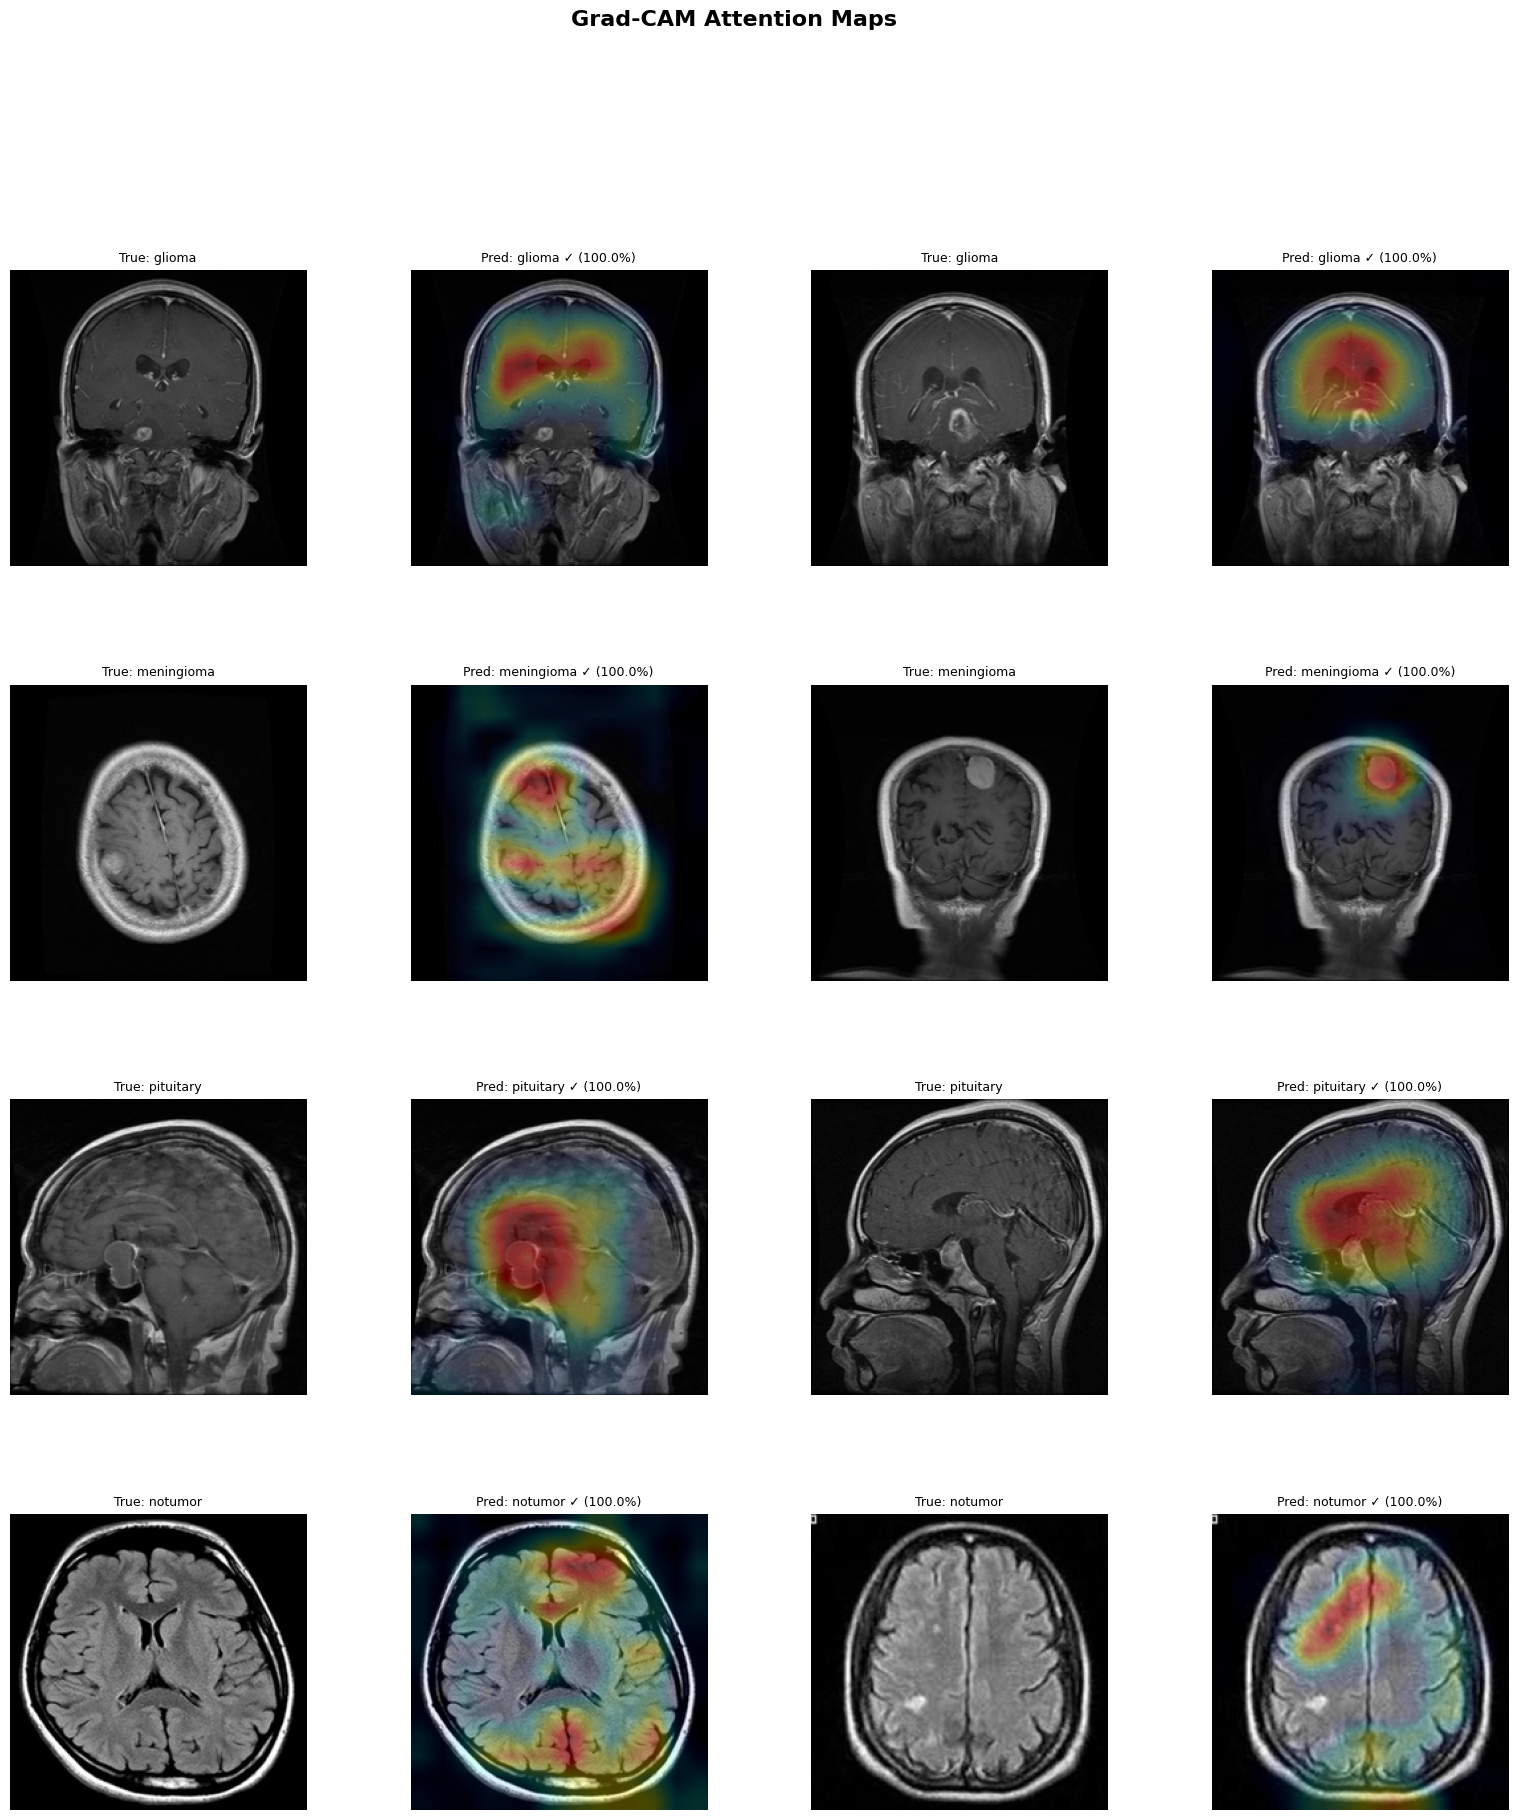

Saved → /kaggle/working/plots/gradcam_grid.png


In [30]:
# Grad-CAM grid — 2 examples per class
N_PER_CLASS = 2
fig = plt.figure(figsize=(5 * N_PER_CLASS * 2, 5 * NUM_CLASSES))
fig.suptitle('Grad-CAM Attention Maps', fontsize=16, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(NUM_CLASSES, N_PER_CLASS * 2, hspace=0.4, wspace=0.15)

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TEST_DIR, cls)
    fnames  = sorted([f for f in os.listdir(cls_dir)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))])[:N_PER_CLASS]

    for col, fname in enumerate(fnames):
        img_path  = os.path.join(cls_dir, fname)
        pil_img   = Image.open(img_path).convert('RGB')
        img_rs    = pil_img.resize(IMG_SIZE, Image.LANCZOS)
        img_arr   = keras_image.img_to_array(img_rs)
        img_pre   = preprocess_input(img_arr.copy())

        probs     = best_model.predict(img_pre[np.newaxis], verbose=0)[0]
        pred_idx  = int(np.argmax(probs))
        conf      = float(probs[pred_idx])
        correct   = (CLASSES[pred_idx] == cls)

        try:
            heatmap = make_gradcam_heatmap(img_pre, best_model, pred_index=pred_idx)
            overlay = overlay_heatmap(heatmap, np.array(img_rs))
        except Exception as e:
            overlay = np.array(img_rs)

        border = '#27AE60' if correct else '#E74C3C'

        ax0 = fig.add_subplot(gs[row, col * 2])
        ax0.imshow(img_rs)
        ax0.set_title(f'True: {cls}', fontsize=9)
        ax0.axis('off')
        for sp in ax0.spines.values():
            sp.set_visible(True); sp.set_color(border); sp.set_linewidth(3)

        ax1 = fig.add_subplot(gs[row, col * 2 + 1])
        ax1.imshow(overlay)
        tick = '✓' if correct else '✗'
        ax1.set_title(f'Pred: {CLASSES[pred_idx]} {tick} ({conf:.1%})', fontsize=9)
        ax1.axis('off')

path = os.path.join(PLOTS_DIR, 'gradcam_grid.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved → {path}")

## 13 — Save Models & Summary

In [31]:
# Save end-of-training model (best checkpoint already saved by ModelCheckpoint)
model.save(FINAL_MODEL_PATH)
print(f"✅ Final model     → {FINAL_MODEL_PATH}")

best_size = os.path.getsize(BEST_MODEL_PATH) / 1e6
print(f"✅ Best checkpoint → {BEST_MODEL_PATH}  ({best_size:.1f} MB)")

best_val_acc = max(
    max(history1.history['val_accuracy']),
    max(history2.history['val_accuracy'])
)

print("\n" + "═"*55)
print("  Training Summary")
print("═"*55)
print(f"  Best val accuracy  : {best_val_acc:.4f}")
print(f"  Macro AUC (test)   : {np.mean(auc_scores):.4f}")
print(f"  Phase 1 duration   : {phase1_time/60:.1f} min")
print(f"  Phase 2 duration   : {phase2_time/60:.1f} min")
print(f"  Total GPU time     : {(phase1_time+phase2_time)/60:.1f} min")
print("═"*55)
print("\n✅ All done! Download models/ from /kaggle/working/")

✅ Final model     → /kaggle/working/models/final_model.keras
✅ Best checkpoint → /kaggle/working/models/brain_tumor_vgg16.keras  (178.3 MB)

═══════════════════════════════════════════════════════
  Training Summary
═══════════════════════════════════════════════════════
  Best val accuracy  : 0.9761
  Macro AUC (test)   : 0.9983
  Phase 1 duration   : 45.4 min
  Phase 2 duration   : 42.1 min
  Total GPU time     : 87.5 min
═══════════════════════════════════════════════════════

✅ All done! Download models/ from /kaggle/working/


## ✅ Training Complete

After the notebook finishes:

1. Go to the **Output** tab on the right side of Kaggle
2. Download `models/brain_tumor_vgg16.keras`
3. Place it in your local project at:
   ```
   BRAIN_TUMOR_DETECTION/
   └── models/
       └── brain_tumor_vgg16.keras   ← replace this file
   ```
4. Run `streamlit run app.py` — everything will work immediately

**All output files saved to `/kaggle/working/`:**
```
models/
├── brain_tumor_vgg16.keras   ← best checkpoint (use this in app.py)
└── final_model.keras

plots/
├── class_distribution.png
├── sample_augmented.png
├── history_phase1.png
├── history_phase2.png
├── history_combined.png
├── confusion_matrix.png
├── roc_curves.png
└── gradcam_grid.png

reports/
└── classification_report.txt
```